<a href="https://colab.research.google.com/github/vilavrenchuk/dz11/blob/main/%D0%9B%D0%B0%D0%B2%D1%80%D0%B5%D0%BD%D1%87%D1%83%D0%BA_%D0%92%D0%B8%D0%BA%D1%82%D0%BE%D1%80%D0%B8%D1%8F_%D0%94%D0%97_11_%D0%9F%D1%80%D0%BE%D0%B3%D1%80%D0%B0%D0%BC%D0%BC%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data_list = [
    {
        "preview": False,
        "offset": 41160,
        "result": {
            "Account_Domain": "WAYNECORPINC",
            "Account_Name": "we3436srv$",
            "ComputerName": "we3436srv.waynecorpinc.local",
            "EventCode": "4688",
            "LogName": "Security",
            "New_Process_Name": "C:\\Program Files\\SplunkUniversalForwarder\\bin\\splunk-winprintmon.exe",
            "signature": "A new process has been created",
            "source": "WinEventLog:Security"
        }
    },
    {
        "preview": False,
        "offset": 41161,
        "result": {
            "Account_Domain": "WAYNECORPINC",
            "Account_Name": "we1159srv$",
            "EventCode": "4689",
            "LogName": "Security",
            "Process_Name": "C:\\Program Files\\SplunkUniversalForwarder\\bin\\splunk-regmon.exe",
            "signature": "A process has exited",
            "source": "WinEventLog:Security"
        }
    },
    {
        "preview": False,
        "offset": 41162,
        "result": {
            "Account_Domain": ["-", "WAYNECORPINC"],
            "Account_Name": ["-", "we9028srv$"],
            "EventCode": "4624",
            "LogName": "Security",
            "signature": "An account was successfully logged on",
            "source": "WinEventLog:Security"
        }
    },
    {
        "preview": False,
        "offset": 41163,
        "result": {
            "Account_Domain": ["WAYNECORPINC", "WAYNECORPINC"],
            "Account_Name": ["we5878srv$", "we5878srv$"],
            "EventCode": "4703",
            "LogName": "Security",
            "signature": "A user right was adjusted",
            "source": "WinEventLog:Security"
        }
    },
    {
        "preview": False,
        "offset": 41164,
        "result": {
            "Account_Name": ["we3997srv$", "we3997srv$"],
            "EventCode": "4703",
            "LogName": "Security",
            "signature": "A user right was adjusted",
            "source": "WinEventLog:Security"
        }
    },
    {
        "preview": False,
        "offset": 41166,
        "result": {
            "Account_Name": "we7127srv$",
            "EventCode": "4689",
            "LogName": "Security",
            "signature": "A process has exited",
            "source": "WinEventLog:Security"
        }
    },
    {
        "preview": False,
        "offset": 41167,
        "result": {
            "Account_Name": ["we5689srv$", "-"],
            "EventCode": "4688",
            "LogName": "Security",
            "signature": "A new process has been created",
            "source": "WinEventLog:Security"
        }
    },
    {
        "preview": False,
        "offset": 41168,
        "result": {
            "Account_Name": ["we1662srv$", "we1662srv$"],
            "EventCode": "4703",
            "LogName": "Security",
            "signature": "A user right was adjusted",
            "source": "WinEventLog:Security"
        }
    },
    {
        "preview": False,
        "offset": 41169,
        "result": {
            "Account_Name": "we3652srv$",
            "EventCode": "4688",
            "LogName": "Security",
            "signature": "A new process has been created",
            "source": "WinEventLog:Security"
        }
    },
    {
        "preview": False,
        "offset": 41170,
        "result": {
            "Account_Name": "we5156srv$",
            "EventCode": "4689",
            "LogName": "Security",
            "signature": "A process has exited",
            "source": "WinEventLog:Security"
        }
    },
    {
        "preview": False,
        "offset": 50001,
        "result": {
            "EventCode": "DNS",
            "LogName": "DNS",
            "QueryName": "google.com",
            "QueryType": "A",
            "ClientIP": "192.168.1.25",
            "source": "Microsoft-Windows-DNS-Client"
        }
    },
    {
        "preview": False,
        "offset": 50002,
        "result": {
            "EventCode": "DNS",
            "LogName": "DNS",
            "QueryName": "ajd92jd9d.com",
            "QueryType": "A",
            "ClientIP": "192.168.1.77",
            "source": "Microsoft-Windows-DNS-Client",
            "eventtype": ["dns", "suspicious"]
        }
    },
    {
        "preview": False,
        "offset": 50003,
        "result": {
            "EventCode": "DNS",
            "LogName": "DNS",
            "QueryName": "c2.maliciousdomain.com",
            "QueryType": "A",
            "ClientIP": "192.168.1.88",
            "source": "Microsoft-Windows-DNS-Client",
            "eventtype": ["dns", "suspicious"]
        }
    }
]

filename = 'botsv1.json'
with open(filename, 'w') as f:
    json.dump(data_list, f)

print(f"Файл {filename} успешно создан в среде Colab!")


Файл botsv1.json успешно создан в среде Colab!


In [9]:
with open(filename, 'r') as f:
  raw_data = json.load(f)

df = pd.json_normalize(raw_data)
df.columns = [col.replace('result.', '') for col in df.columns]

print("Данные загружены в DataFrame. Размер:", df.shape)

display(df[['EventCode', 'LogName', 'signature', 'QueryName']].head())

Данные загружены в DataFrame. Размер: (13, 15)


,EventCode,LogName,signature,QueryName
0,4688,Security,A new process has been created,NaN
1,4689,Security,A process has exited,NaN
2,4624,Security,An account was successfully logged on,NaN
3,4703,Security,A user right was adjusted,NaN
4,4703,Security,A user right was adjusted,NaN


In [10]:
win_df = df[df['LogName'] == 'Security'].copy()
win_stats = win_df['signature'].value_counts().reset_index()
win_stats.columns = ['Description', 'Count']
win_stats['Type'] = 'Windows Event'

dns_df = df[df['LogName'] == 'DNS'].copy()
dns_stats = dns_df['QueryName'].value_counts().reset_index()
dns_stats.columns = ['Description', 'Count']
dns_stats['Type'] = 'DNS Query'

print("\nПодозрительные DNS запросы")
print(dns_stats)


Подозрительные DNS запросы
              Description  Count       Type
0              google.com      1  DNS Query
1           ajd92jd9d.com      1  DNS Query
2  c2.maliciousdomain.com      1  DNS Query


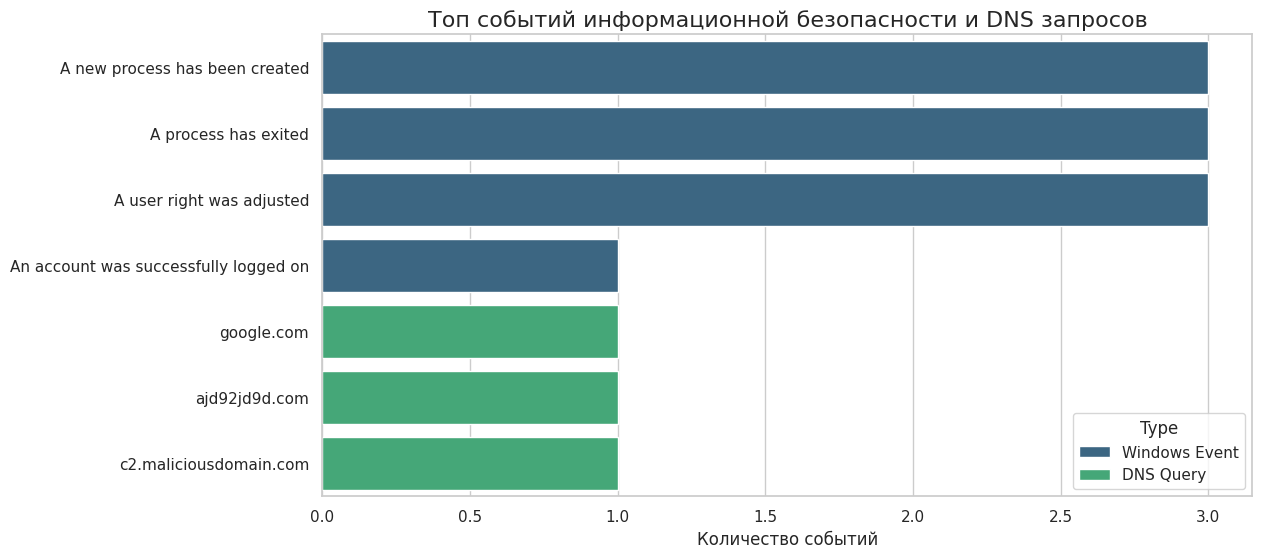

In [11]:
combined_stats = pd.concat([win_stats, dns_stats])
top_events = combined_stats.sort_values(by='Count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

barplot = sns.barplot(
    data=top_events,
    y='Description',
    x='Count',
    hue='Type',
    dodge=False,
    palette='viridis'
)

plt.title('Топ событий информационной безопасности и DNS запросов', fontsize=16)
plt.xlabel('Количество событий', fontsize=12)
plt.ylabel('')
plt.show()

